In [1]:
import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [2]:
class MAEImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        assert len(self.image_files) > 0, f"No images found in the directory {root_dir}"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.root_dir, self.image_files[idx])
        img = Image.open(image_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


In [3]:
mae_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])  

In [4]:
train_path = "../data/data1/train"
valid_path = "../data/data1/valid"
test_path = "../data/data1/test"

train_dataset = MAEImageDataset(train_path, transform=mae_transform)
valid_dataset = MAEImageDataset(valid_path, transform=mae_transform)
test_dataset = MAEImageDataset(test_path, transform=mae_transform)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 3303
Valid: 312
Test : 156


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory = False
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory = False
)

In [6]:
images = next(iter(valid_loader))
print(images.shape)

torch.Size([32, 3, 224, 224])


In [7]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_chans,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x
        

In [8]:
class MAE(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768, depth=12, 
                 num_head=12, decoder_embed_dim=384, decoder_depth=6, decoder_num_head=6, mask_ratio=0.3):
        super().__init__()
        self.mask_ratio = mask_ratio

        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches, embed_dim),
            requires_grad=False
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_head,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_embed_dim,
            nhead=decoder_num_head,
            batch_first=True
        )

        self.decoder = nn.TransformerEncoder(
            decoder_layer,
            num_layers=decoder_depth
        )

        self.decoder_pred = nn.Linear(
            decoder_embed_dim,
            patch_size * patch_size * in_chans,
            bias=True
        )

        self.initialize_weights()

    def initialize_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)

    def random_masking(self, x):
        B, N, D = x.shape
        
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]

        x_masked = torch.gather(
            x,
            dim=1,
            index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
        )

        mask = torch.ones([B, N], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward(self, imgs):
        
        x = self.patch_embed(imgs)
        x = x + self.pos_embed

        x_masked, mask, ids_restore = self.random_masking(x)

        latent = self.encoder(x_masked)

        x = self.decoder_embed(latent)

        B, N, D = x.shape
        mask_tokens = self.mask_token.repeat(
            B, ids_restore.shape[1] - N, 1
        )

        x_ = torch.cat([x, mask_tokens], dim=1)
        x_ = torch.gather(
            x_, dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1, 1, D)
        )

        x = self.decoder(x_)
        pred = self.decoder_pred(x)

        return pred, mask

    def mae_loss(pred, imgs, patch_size=16):
        B, _, _ = pred.shape
    
        target = imgs.reshape(
            B, 3,
            imgs.shape[2] // patch_size, patch_size,
            imgs.shape[3] // patch_size, patch_size
        )
        target = target.permute(0, 2, 4, 3, 5, 1)
        target = target.reshape(B, -1, patch_size * patch_size * 3)
    
        loss = (pred - target) ** 2
        return loss.mean()
        

In [9]:
model = MAE()
imgs = next(iter(train_loader))
pred, mask = model(imgs)

print(pred.shape)
print(mask.shape)


torch.Size([32, 196, 768])
torch.Size([32, 196])


In [10]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

model = MAE().to(device)

Using device: mps


In [11]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.05
)


In [12]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for imgs in loader:
        imgs = imgs.to(device)

        pred, mask = model(imgs)
        loss = mae_loss(pred, imgs, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [13]:
def mae_loss(pred, imgs, mask, patch_size=16):
    B = imgs.shape[0]

    target = imgs.reshape(
        B, 3,
        imgs.shape[2] // patch_size, patch_size,
        imgs.shape[3] // patch_size, patch_size
    )
    target = target.permute(0, 2, 4, 3, 5, 1)
    target = target.reshape(B, -1, patch_size * patch_size * 3)

    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)          
    loss = (loss * mask).sum() / mask.sum()

    return loss


In [14]:
@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_loss = 0.0

    for imgs in loader:
        imgs = imgs.to(device)
        pred, mask = model(imgs)
        loss = mae_loss(pred, imgs, mask)
        total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
num_epochs = 100

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, device
    )

    val_loss = validate(
        model, valid_loader, device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )


Epoch [1/100] Train Loss: 0.3548 Val Loss: 0.2313
Epoch [2/100] Train Loss: 0.2945 Val Loss: 0.2221
Epoch [3/100] Train Loss: 0.2903 Val Loss: 0.2211
Epoch [4/100] Train Loss: 0.2876 Val Loss: 0.2232
Epoch [5/100] Train Loss: 0.2871 Val Loss: 0.2202
Epoch [6/100] Train Loss: 0.2883 Val Loss: 0.2160
Epoch [7/100] Train Loss: 0.2853 Val Loss: 0.2234
Epoch [8/100] Train Loss: 0.2860 Val Loss: 0.2202
Epoch [9/100] Train Loss: 0.2853 Val Loss: 0.2193
Epoch [10/100] Train Loss: 0.2848 Val Loss: 0.2159
Epoch [11/100] Train Loss: 0.2840 Val Loss: 0.2205
Epoch [12/100] Train Loss: 0.2839 Val Loss: 0.2199
Epoch [13/100] Train Loss: 0.2833 Val Loss: 0.2194
Epoch [14/100] Train Loss: 0.2838 Val Loss: 0.2169
Epoch [15/100] Train Loss: 0.2840 Val Loss: 0.2198
Epoch [16/100] Train Loss: 0.2833 Val Loss: 0.2175
Epoch [17/100] Train Loss: 0.2829 Val Loss: 0.2176
Epoch [18/100] Train Loss: 0.2815 Val Loss: 0.2209
Epoch [19/100] Train Loss: 0.2828 Val Loss: 0.2162
Epoch [20/100] Train Loss: 0.2823 Val Lo

In [16]:
def unpatchify(patches, patch_size=16):
    h = w = int(patches.shape[0] ** 0.5)
    patches = patches.reshape(
        h, w, patch_size, patch_size, 3
    )
    patches = patches.permute(0, 2, 1, 3, 4)
    img = patches.reshape(
        h * patch_size, w * patch_size, 3
    )
    return img

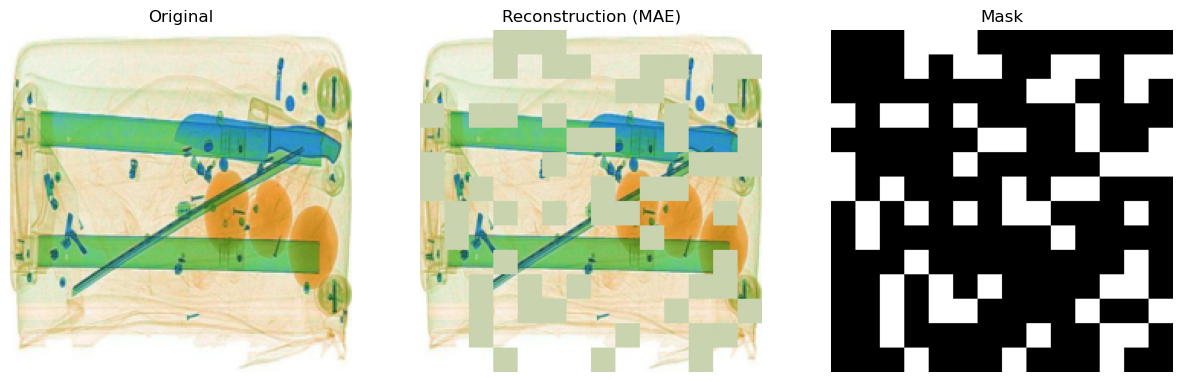

In [17]:
model.eval()
imgs = next(iter(valid_loader))
imgs = imgs.to(device)

with torch.no_grad():
    pred, mask = model(imgs)

img = imgs[0].cpu()                
pred_patches = pred[0].cpu()       
mask_patches = mask[0].cpu()       

patch_size = 16
H, W = img.shape[1], img.shape[2]

target = img.reshape(
    3,
    H // patch_size, patch_size,
    W // patch_size, patch_size
)
target = target.permute(1, 3, 2, 4, 0)
target = target.reshape(-1, patch_size * patch_size * 3)

recon_full = pred_patches.clone()
visible = (mask_patches == 0)
recon_full[visible] = target[visible]

orig_img = img.permute(1, 2, 0)
recon_img = unpatchify(recon_full, patch_size)

mask_img = unpatchify(
    mask_patches.unsqueeze(-1).repeat(1, patch_size * patch_size * 3),
    patch_size
)

orig_img  = orig_img * 0.5 + 0.5
recon_img = recon_img * 0.5 + 0.5

# --- plot ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(orig_img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Reconstruction (MAE)")
plt.imshow(recon_img)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Mask")
plt.imshow(mask_img[:, :, 0], cmap="gray")
plt.axis("off")

plt.show()


28/1/2026

## Result comparison

### 75% Masked, 10 Epoch 
![MAE 75% 10 epoch](../results/28_1_2026/R1.png)
### 50% Masked, 50 Epoch 
![MAE 75% 10 epoch](../results/28_1_2026/R2.png)
### 30% Masked, 100 Epoch 
![MAE 75% 10 epoch](../results/28_1_2026/R3.png)
